# Diffusion Model from Scratch — Lightweight DDPM

A CPU-friendly implementation of a Denoising Diffusion Probabilistic Model (DDPM) for MNIST. The notebook builds the forward diffusion process, a compact denoising network, the noise-prediction loss, and the reverse sampling loop directly in PyTorch.

In [7]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
torch.manual_seed(42)
DEVICE=torch.device('cpu')
TRAIN_SAMPLES=5000; EPOCHS=2; BATCH_SIZE=64; T=100; LR=2e-4; IMAGE_SIZE=28
DATA_DIR=Path('../data'); ARTIFACT_DIR=Path('../artifacts'); ARTIFACT_DIR.mkdir(exist_ok=True)
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
train_full=datasets.MNIST(DATA_DIR,train=True,download=True,transform=transform)
train_set=Subset(train_full,range(min(TRAIN_SAMPLES,len(train_full))))
loader=DataLoader(train_set,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
print('Device:',DEVICE,'Training images:',len(train_set))

Device: cpu Training images: 5000


## Forward diffusion

Noise is added according to a linear beta schedule. The cumulative product of alpha values allows a clean image to be sampled directly at any timestep.

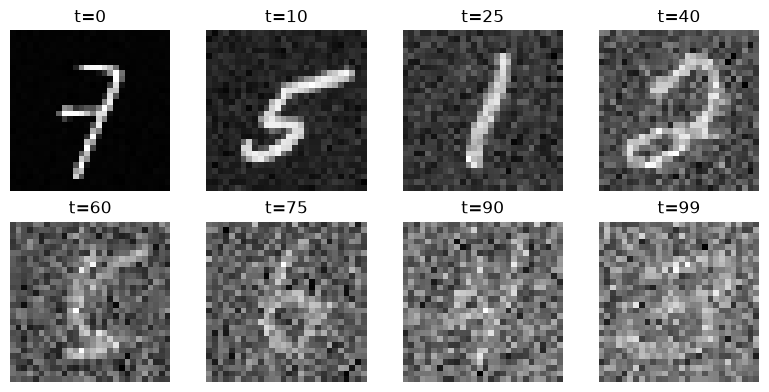

In [8]:
betas=torch.linspace(1e-4,0.02,T,device=DEVICE)
alphas=1-betas
alpha_bars=torch.cumprod(alphas,0)
def add_noise(x0,t):
    noise=torch.randn_like(x0); abar=alpha_bars[t].view(-1,1,1,1)
    return torch.sqrt(abar)*x0+torch.sqrt(1-abar)*noise,noise
images,_=next(iter(loader)); images=images[:8]
timesteps=torch.tensor([0,10,25,40,60,75,90,99]); noisy,_=add_noise(images,timesteps)
fig,axes=plt.subplots(2,4,figsize=(8,4))
for ax,image,step in zip(axes.ravel(),noisy,timesteps): ax.imshow(image[0],cmap='gray'); ax.set_title(f't={int(step)}'); ax.axis('off')
plt.tight_layout()

## Compact denoising network

The network receives a noisy image and the timestep. It learns to predict the Gaussian noise that was added.

In [9]:
class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time=nn.Sequential(nn.Linear(1,32),nn.SiLU(),nn.Linear(32,32),nn.SiLU())
        self.down=nn.Sequential(nn.Conv2d(1,32,3,padding=1),nn.SiLU(),nn.Conv2d(32,64,3,stride=2,padding=1),nn.SiLU())
        self.mid=nn.Sequential(nn.Conv2d(64,64,3,padding=1),nn.SiLU())
        self.up=nn.Sequential(nn.ConvTranspose2d(64,32,4,stride=2,padding=1),nn.SiLU(),nn.Conv2d(32,1,3,padding=1))
    def forward(self,x,t):
        emb=self.time((t.float()/T).view(-1,1)).view(-1,32,1,1)
        h=self.down(x); h=h+emb.repeat(1,2,1,1); return self.up(self.mid(h))
model=TinyDenoiser().to(DEVICE); optimizer=torch.optim.Adam(model.parameters(),lr=LR)
print('Parameters:',sum(p.numel() for p in model.parameters()))

Parameters: 89953


## Train

For every batch, choose a random timestep, create its noisy image, predict the noise, and minimize MSE between actual and predicted noise.

Epoch 1/2 - loss: 0.8526
Epoch 2/2 - loss: 0.4368


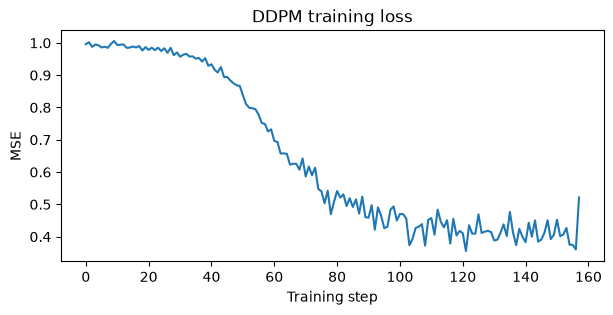

In [10]:
loss_history=[]; model.train()
for epoch in range(EPOCHS):
    running=0.0
    for step,(x0,_) in enumerate(loader,1):
        t=torch.randint(0,T,(x0.size(0),),device=DEVICE); xt,noise=add_noise(x0,t)
        predicted_noise=model(xt,t); loss=F.mse_loss(predicted_noise,noise)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running+=loss.item(); loss_history.append(loss.item())
    print(f'Epoch {epoch+1}/{EPOCHS} - loss: {running/step:.4f}')
plt.figure(figsize=(7,3)); plt.plot(loss_history); plt.title('DDPM training loss'); plt.xlabel('Training step'); plt.ylabel('MSE'); plt.show()

## Reverse diffusion sampling

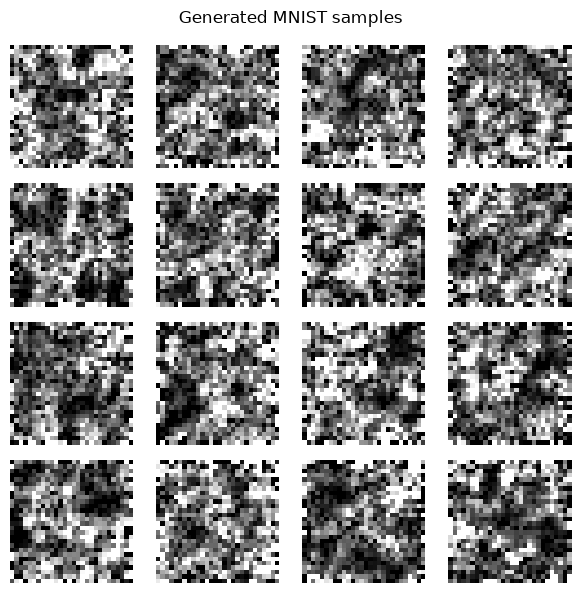

In [11]:
@torch.no_grad()
def sample(model,n=16):
    model.eval(); x=torch.randn(n,1,IMAGE_SIZE,IMAGE_SIZE,device=DEVICE)
    for step in reversed(range(T)):
        t=torch.full((n,),step,device=DEVICE,dtype=torch.long); pred=model(x,t)
        alpha=alphas[step]; abar=alpha_bars[step]; beta=betas[step]
        mean=(x-(beta/torch.sqrt(1-abar))*pred)/torch.sqrt(alpha)
        x=mean+torch.sqrt(beta)*torch.randn_like(x) if step>0 else mean
    return x.clamp(-1,1)
samples=sample(model).cpu(); fig,axes=plt.subplots(4,4,figsize=(6,6))
for ax,image in zip(axes.ravel(),samples): ax.imshow((image[0]+1)/2,cmap='gray'); ax.axis('off')
plt.suptitle('Generated MNIST samples'); plt.tight_layout()

In [12]:
checkpoint_path=ARTIFACT_DIR/'ddpm_mnist.pt'
torch.save(model.state_dict(),checkpoint_path)
print('Saved:',checkpoint_path.resolve())

Saved: C:\Users\user\Desktop\Diffusion-Model-from-Scratch\artifacts\ddpm_mnist.pt


## Interview talking points

- Forward process: gradually corrupt data with Gaussian noise.
- Reverse process: learn a denoiser that predicts the noise at each timestep.
- Loss: MSE between sampled and predicted noise.
- CPU trade-off: 28×28 MNIST and a tiny network keep the project practical.
- Scaling path: larger U-Nets, better time embeddings, schedules, datasets and compute.

Run the final cell to save the checkpoint used by the Django demo.